# Module 11 — Pretraining in Practice (notebook)

A CPU-friendly walkthrough of the full pretraining pipeline. Five sections:

1. **Load the config** — what the demo run actually trains on.
2. **The data pipeline** — `SyntheticDataset` for offline, `FineWebEduDataset` for real.
3. **One step of training** — build model + optimizer + scheduler + run a single `train_step`.
4. **Memory and FLOP budget** — verify the demo fits where we said it does.
5. **Reading a (mock) loss curve** — what the training trajectory looks like.

This notebook never launches the full ~3-billion-token run (that needs an A100). It does run the full code path end-to-end on a synthetic dataset so you can see every component, end to end, on a laptop in under a minute.

## 1. The demo config

Load `configs/demo_a100.yaml` through the `TrainConfig` dataclass tree. The fields below are the actual numbers the demo run uses on a single A100. The H100-tuned twin lives at `configs/demo_h100.yaml` and differs in a single field (`activation_checkpointing: false`) — same model, same token budget, just dropping the ~33% AC FLOP tax that H100 has the memory to afford.

In [ ]:
from config import load_yaml

cfg = load_yaml("configs/demo_a100.yaml")

def row(label, val): print(f"  {label:30s} {val}")
print("MODEL")
row("vocab_size",   cfg.model.vocab_size)
row("d_model x n_layers",  f"{cfg.model.d_model} x {cfg.model.n_layers}")
row("n_heads (q / kv)",    f"{cfg.model.n_heads} / {cfg.model.n_kv_heads}")
row("d_ffn",   cfg.model.d_ffn)
row("max_seq", cfg.model.max_seq)
print("\nOPTIMIZER + SCHEDULE")
row("type",       cfg.optimizer.type)
row("peak lr",    cfg.optimizer.lr)
row("schedule",   f"{cfg.schedule.type}, warmup={cfg.schedule.warmup_steps}, min_lr_ratio={cfg.schedule.min_lr_ratio}")
print("\nDATA + TRAINING")
row("source",                cfg.data.source)
row("seq_len",               cfg.data.seq_len)
row("batch_size_per_device", cfg.data.batch_size_per_device)
row("grad_accum",            cfg.training.grad_accum)
tok_per_step = cfg.data.batch_size_per_device * cfg.data.seq_len * cfg.training.grad_accum
row("tokens/step (1 GPU)",   f"{tok_per_step:,}")
row("total_steps",           cfg.training.total_steps)
row("total tokens (1 GPU)",  f"{tok_per_step * cfg.training.total_steps / 1e9:.2f} B")
row("activation_checkpointing", cfg.training.activation_checkpointing)
row("dtype",                 cfg.training.dtype)

## 2. The data pipeline

Two implementations in `data.py`:

- `SyntheticDataset` — random tokens, no internet. Used here so the notebook runs offline.
- `FineWebEduDataset` — streams `HuggingFaceFW/fineweb-edu`, tokenizes with `Qwen/Qwen3-0.6B`'s tokenizer, packs documents into `seq_len`-block samples.

Both produce dicts with `input_ids` (shape `(B, seq_len)`) and `labels` (`input_ids` shifted by +1). The shift happens **in the dataset, once** — `loop.py`'s `forward_loss` then calls `model(input_ids=...)` (no `labels=` kwarg) and computes cross-entropy itself against `batch["labels"]`. That keeps the loop architecture-agnostic: any module whose forward returns logits works, whether HF Qwen3, HF Llama, or a custom Part-2-style `TransformerLM`.

We override the demo config to use `synthetic` + tiny shape so this runs in seconds.

In [ ]:
import torch
from config import TrainConfig, DataConfig
from data import make_dataloader, cycle

# Build a tiny notebook config (CPU-friendly).
nb_cfg = TrainConfig()
nb_cfg.data.source = "synthetic"
nb_cfg.data.seq_len = 64
nb_cfg.data.batch_size_per_device = 2
nb_cfg.data.num_workers = 0
nb_cfg.data.synthetic_samples = 50
nb_cfg.model.vocab_size = 2048
nb_cfg.model.d_model = 64
nb_cfg.model.n_layers = 2
nb_cfg.model.n_heads = 2
nb_cfg.model.n_kv_heads = 1
nb_cfg.model.d_ffn = 128
nb_cfg.model.max_seq = 64
nb_cfg.training.dtype = "fp32"
nb_cfg.training.activation_checkpointing = False
nb_cfg.training.grad_accum = 1
nb_cfg.training.total_steps = 5
nb_cfg.schedule.total_steps = 5
nb_cfg.schedule.warmup_steps = 2

# make_dataloader returns (loader, sampler). For streaming/synthetic the sampler
# is None; only source="indexed" (Module 12) returns a resumable sampler.
loader, _ = make_dataloader(nb_cfg.data, vocab_size=nb_cfg.model.vocab_size)
it = cycle(loader)
batch = next(it)

print(f"input_ids shape: {tuple(batch['input_ids'].shape)}  dtype: {batch['input_ids'].dtype}")
print(f"labels    shape: {tuple(batch['labels'].shape)}  dtype: {batch['labels'].dtype}")
print(f"\nverify the +1 shift (labels[t] == input_ids[t+1]):")
print(f"  input_ids[0, 1:6] = {batch['input_ids'][0, 1:6].tolist()}")
print(f"  labels[0,    0:5] = {batch['labels'][0,    0:5].tolist()}")
print(f"  match? {torch.equal(batch['input_ids'][:, 1:], batch['labels'][:, :-1])}")

## 3. One step of training

Build everything the way `train.py` does, run 5 steps, and watch loss + grad_norm + lr move. The loop's `train_step` handles gradient accumulation + clipping; the scheduler ticks once per optimizer step.

In [ ]:
from model import build_model, count_params
from optim import build_optimizer
from schedule import build_scheduler
from loop import train_step

torch.manual_seed(0)
model = build_model(nb_cfg.model)
counts = count_params(model)
print(f"model: {counts['total']/1e6:.2f}M params  "
      f"(embed {counts['embedding']/1e6:.2f}M, "
      f"attn {counts['attention']/1e6:.2f}M, "
      f"mlp {counts['mlp']/1e6:.2f}M)")

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
optimizer = build_optimizer(model, nb_cfg.optimizer)
scheduler = build_scheduler(optimizer, nb_cfg.schedule)

loader, _ = make_dataloader(nb_cfg.data, vocab_size=nb_cfg.model.vocab_size)
batch_iter = cycle(loader)

print(f"\nrunning {nb_cfg.training.total_steps} steps on {device}:")
print(f"  expected loss-at-init ≈ ln({nb_cfg.model.vocab_size}) "
      f"= {torch.log(torch.tensor(float(nb_cfg.model.vocab_size))).item():.3f}")
print()

history = []
model.train()
for step in range(nb_cfg.training.total_steps):
    loss, gn = train_step(
        model=model, optimizer=optimizer, batch_iter=batch_iter,
        grad_accum=nb_cfg.training.grad_accum,
        grad_clip=nb_cfg.training.grad_clip,
        dtype=nb_cfg.training.dtype, device=device,
    )
    scheduler.step()
    lr = optimizer.param_groups[0]["lr"]
    history.append((step, loss, gn, lr))
    print(f"  step {step}  loss {loss:.4f}  grad_norm {gn:.3f}  lr {lr:.2e}")

## 4. Memory and FLOP budget for the demo

Using Module 10's `efficiency.py` to estimate where the bytes go on a real A100 at the demo's full 150M shape. This is the math you'd use to decide whether a config fits before you launch.

In [4]:
from efficiency import memory_breakdown, training_flops

# Build the demo model just to get the real param count.
demo_model = build_model(cfg.model)
n_params = sum(p.numel() for p in demo_model.parameters())
del demo_model
print(f"demo model param count: {n_params/1e6:.1f}M  "
      f"(vocab {cfg.model.vocab_size} × d {cfg.model.d_model} embedding "
      f"dominates: {cfg.model.vocab_size * cfg.model.d_model / 1e6:.1f}M)")

# Memory budget — single A100, with and without activation checkpointing.
GB = 1024**3
geom = dict(n_layers=cfg.model.n_layers, batch_size=cfg.data.batch_size_per_device,
            seq_len=cfg.data.seq_len, d_model=cfg.model.d_model)

print("\nPer-rank memory (single A100, BF16 + AdamW, no sharding):")
for ac in (False, True):
    b = memory_breakdown(n_params=n_params, dtype="bf16", optimizer="adamw",
                        zero_stage=0, world_size=1,
                        activation_checkpointing=ac, **geom)
    label = "+ activation checkpointing" if ac else "no checkpointing"
    print(f"\n  {label}:")
    print(f"    master_weights   {b.master_weights/GB:6.2f} GB")
    print(f"    compute_weights  {b.compute_weights/GB:6.2f} GB")
    print(f"    gradients        {b.gradients/GB:6.2f} GB")
    print(f"    optimizer_state  {b.optimizer_state/GB:6.2f} GB")
    print(f"    activations      {b.activations/GB:6.2f} GB")
    print(f"    total            {b.total/GB:6.2f} GB")
    print(f"    headroom on 80GB {80 - b.total/GB:6.2f} GB")

# FLOP budget
tokens_per_step = (cfg.data.batch_size_per_device * cfg.data.seq_len
                   * cfg.training.grad_accum)
total_tokens = tokens_per_step * cfg.training.total_steps
total_flops = training_flops(n_params, total_tokens)
print(f"\nFLOP budget:")
print(f"  6ND total flops      {total_flops:.2e}")
print(f"  ratio D/N            {total_tokens/n_params:.1f}  (Chinchilla target: 20)")
a100_bf16_tflops = 312
hours_at_50pct = total_flops / (a100_bf16_tflops * 1e12 * 0.5) / 3600
print(f"  hours @ 50% MFU      {hours_at_50pct:.1f} h  (one A100)")
print(f"  hours @ 25% MFU      {hours_at_50pct*2:.1f} h")

demo model param count: 206.4M  (vocab 151936 × d 768 embedding dominates: 116.7M)

Per-rank memory (single A100, BF16 + AdamW, no sharding):

  no checkpointing:
    master_weights     0.77 GB
    compute_weights    0.38 GB
    gradients          0.38 GB
    optimizer_state    1.54 GB
    activations        2.81 GB
    total              5.89 GB
    headroom on 80GB  74.11 GB

  + activation checkpointing:
    master_weights     0.77 GB
    compute_weights    0.38 GB
    gradients          0.38 GB
    optimizer_state    1.54 GB
    activations        0.23 GB
    total              3.31 GB
    headroom on 80GB  76.69 GB

FLOP budget:
  6ND total flops      3.89e+18
  ratio D/N            15.2  (Chinchilla target: 20)
  hours @ 50% MFU      6.9 h  (one A100)
  hours @ 25% MFU      13.9 h


## 5. Reading a loss curve

We can't easily run 3 billion tokens here, so we **simulate** what the demo's loss curve looks like. The shape is what you should expect: a steep early drop (random model → "frequent tokens are frequent"), the warmup-cosine LR overlay, and a flattening tail.

Use this as a calibration. If your real run's curve looks substantially different, suspect a config bug before suspecting the data.

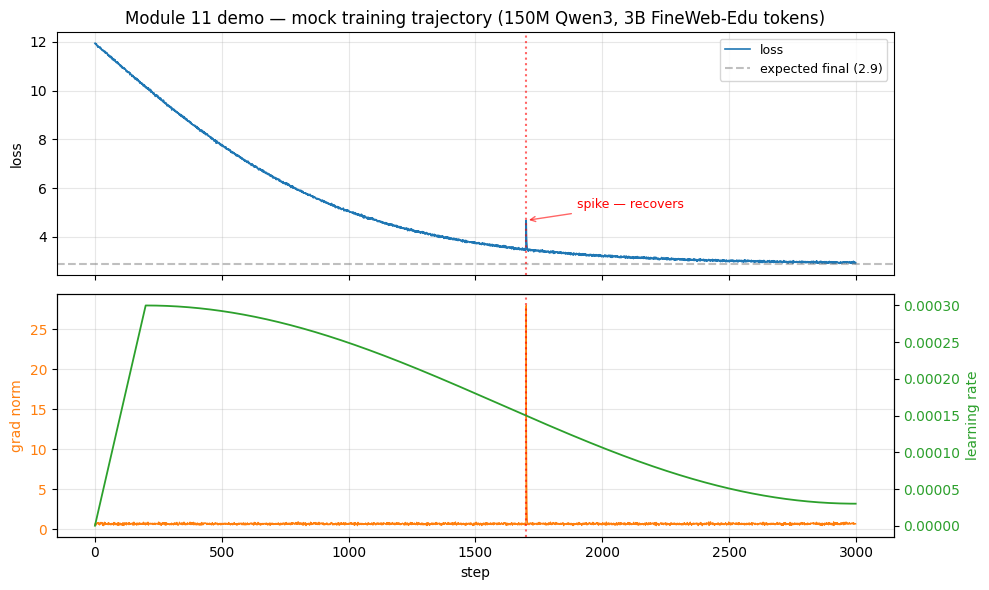

What this curve tells you:
  - Warmup visible as the LR ramp over the first 200 steps.
  - Loss drops sharply during warmup as the model picks up token frequency.
  - Cosine decay slows learning gracefully; the final tail is the small
    refinements that move perplexity by a few percent.
  - The synthetic spike at step 1700 shows what a bad batch looks like:
    grad_norm jumps to ~28, loss bumps by ~1.2, then recovers in <5 steps.
    Clipping at 1.0 prevented this from killing the run.


In [5]:
import math
import numpy as np
import matplotlib.pyplot as plt

total_steps = cfg.training.total_steps
warmup_steps = cfg.schedule.warmup_steps
peak_lr = cfg.optimizer.lr
min_lr = peak_lr * cfg.schedule.min_lr_ratio
loss_init = math.log(cfg.model.vocab_size)        # ~11.93
loss_final = 2.9                                  # expected demo ending

# LR trajectory (warmup-cosine)
steps = np.arange(total_steps)
lr = np.empty_like(steps, dtype=float)
for t in steps:
    if t < warmup_steps:
        lr[t] = peak_lr * t / max(1, warmup_steps)
    else:
        progress = (t - warmup_steps) / (total_steps - warmup_steps)
        lr[t] = min_lr + (peak_lr - min_lr) * 0.5 * (1 + math.cos(math.pi * progress))

# Loss trajectory: a power-law decay with a small mid-run wiggle + a spike to
# show what gradient-norm signatures look like. This is not a real run; it's a
# calibration sketch.
rng = np.random.default_rng(0)
progress = np.arange(total_steps) / total_steps
# Hoffmann-style power law: loss = a + b * progress^(-c). We fit to start/end.
loss_clean = loss_final + (loss_init - loss_final) * (1 - np.tanh(3 * progress))
loss_noise = rng.normal(0, 0.02, size=total_steps)
loss = loss_clean + loss_noise
# Inject a single spike at step 1700 — the kind of thing you'd recover from.
spike = 1700
loss[spike] += 1.2
loss[spike+1:spike+5] += np.array([0.6, 0.3, 0.15, 0.05])

# Grad norm: stable ~ 0.7, with the same single spike.
gn = rng.normal(0.7, 0.08, size=total_steps).clip(0.1, None)
gn[spike] = 28.0
gn[spike+1:spike+5] = [12, 6, 3, 1.5]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

ax1.plot(loss, lw=1.2, color="tab:blue", label="loss")
ax1.axhline(loss_final, ls="--", color="gray", alpha=0.5, label=f"expected final ({loss_final})")
ax1.axvline(spike, ls=":", color="red", alpha=0.6)
ax1.annotate("spike — recovers", xy=(spike, loss[spike]), xytext=(spike+200, loss[spike]+0.5),
             fontsize=9, color="red",
             arrowprops=dict(arrowstyle="->", color="red", alpha=0.6))
ax1.set_ylabel("loss")
ax1.set_title("Module 11 demo — mock training trajectory (150M Qwen3, 3B FineWeb-Edu tokens)")
ax1.legend(loc="upper right", fontsize=9)
ax1.grid(alpha=0.3)

ax2.plot(gn, lw=0.9, color="tab:orange", label="grad_norm")
ax2_lr = ax2.twinx()
ax2_lr.plot(lr, lw=1.3, color="tab:green", label="lr")
ax2_lr.set_ylabel("learning rate", color="tab:green")
ax2_lr.tick_params(axis="y", labelcolor="tab:green")
ax2.set_xlabel("step")
ax2.set_ylabel("grad norm", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")
ax2.axvline(spike, ls=":", color="red", alpha=0.6)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("What this curve tells you:")
print("  - Warmup visible as the LR ramp over the first 200 steps.")
print("  - Loss drops sharply during warmup as the model picks up token frequency.")
print("  - Cosine decay slows learning gracefully; the final tail is the small")
print("    refinements that move perplexity by a few percent.")
print("  - The synthetic spike at step 1700 shows what a bad batch looks like:")
print("    grad_norm jumps to ~28, loss bumps by ~1.2, then recovers in <5 steps.")
print("    Clipping at 1.0 prevented this from killing the run.")